In [2]:
import numpy as np
import matplotlib.pyplot as plt

from simulator import Scene, gaussian_map, carrier_map, random_dips, beam_intensity, masked_map, rectangle, circle
from simulator.basis import poly_modes
from simulator.sequences import uniform_steps, linear_steps

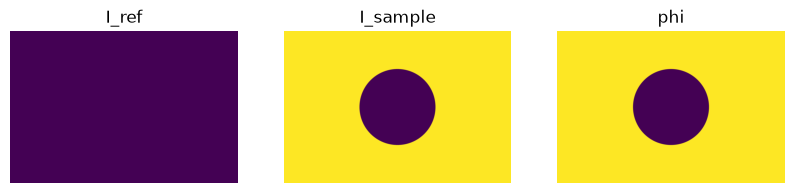

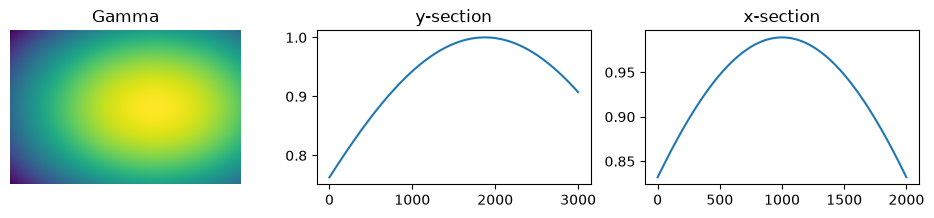

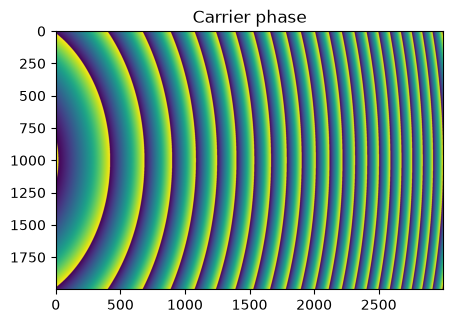

In [4]:
H = 2000 # height in pixels
W = 3000 # width in pixels

# Prepare intenisties of the beams and their phase difference
I_ref = masked_map(rectangle(H, W, H//2, W//2), 1.0, 1.0)
I_sample = masked_map(circle(H, W, H//4), 0.7, 1.0)
phi = masked_map(circle(H, W, H//4), 0.5, 1.0) * np.pi

plt.figure(figsize=(10,5))
plt.subplot(131)
plt.title('I_ref')
plt.imshow(I_ref[0])
plt.axis('off')

plt.subplot(132)
plt.title('I_sample')
plt.imshow(I_sample[0])
plt.axis('off')

plt.subplot(133)
plt.title('phi')
plt.imshow(phi[0])
plt.axis('off')

# Setup coherence envelope (gamma)
gamma = gaussian_map(H,W, (2*W,2*H), center=(W//2 + W//8, H//2))

plt.figure(figsize=(12, 2))
plt.subplot(131)
plt.title('Gamma')
plt.imshow(gamma[0])
plt.axis('off')

plt.subplot(132)
plt.title('y-section')
plt.plot(gamma[0,H//2])

plt.subplot(133)
plt.title('x-section')
plt.plot(gamma[0,:,W//2])

# Setup carrier
carrier=[40.0, 0.0, 8.0, 0.0, 2.0]
carrier_2d = carrier_map(H, W, carrier)

plt.figure(figsize=(5,5))
plt.title('Carrier phase')
plt.imshow(np.angle(np.exp(1j*carrier_2d[0])))

In [ ]:
# AIA for different number of frames with uniform steps / linear steps + noise / random steps
import warnings

from phase_shift import PhaseConfig, PhaseSolver
from phase_shift.backend import asnumpy
from phase_shift.utils import wrap
from simulator.sequences import random_steps

N = 20
num = np.arange(start=3, stop=N)

pistons = {
    "uniform, 2πn/N": lambda n: uniform_steps(n),
    "linear π/2 + noise 0.3 rad": lambda n: linear_steps(n, np.pi / 2, sigma=0.3, rng=n),
    "random in [0, 2π)": lambda n: random_steps(n, rng=n),
}
config = PhaseConfig(gain_mode="none", use_alpha=False, method_kwargs={"iters": 30, "tol": 1.0e-4})   # simulated alpha = g = 1
phi_true = phi[0] + carrier_2d[0]                          # AIA recovers the total static phase


def phase_rmse(phi_rec, phi_true):
    """Wrap-aware RMSE after resolving the global sign and piston ambiguity."""
    errors = []
    for sign in (1, -1):
        d = wrap(sign * phi_rec - phi_true)
        d = wrap(d - np.angle(np.mean(np.exp(1j * d))))
        errors.append(np.sqrt(np.mean(d ** 2)))
    return min(errors)


def aia_rmse(piston):
    stack = Scene(I_sample, I_ref, gamma, phi, piston, carrier=carrier).ideal()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        result = PhaseSolver(config).fit(stack.astype(np.float32)).result
    return phase_rmse(asnumpy(result.phi), phi_true)


rmse = {}
for name, make in pistons.items():
    rmse[name] = [aia_rmse(make(n)) for n in num]
    print(f"{name}: done")

plt.figure(figsize=(7, 4.5))
for name, values in rmse.items():
    plt.semilogy(num, values, "o-", ms=4, label=name)
plt.xlabel("number of frames N")
plt.ylabel("phase RMSE (rad)")
plt.title("AIA, noise-free")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()

uniform, 2πn/N: done


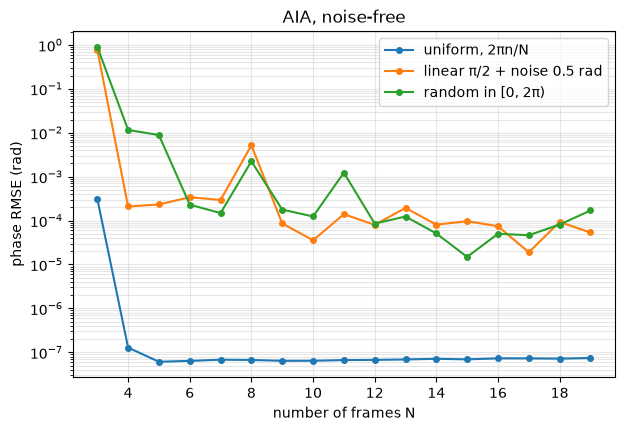

In [9]:
plt.figure(figsize=(7, 4.5))
for name, values in rmse.items():
    plt.semilogy(num, values, "o-", ms=4, label=name)
plt.xlabel("number of frames N")
plt.ylabel("phase RMSE (rad)")
plt.title("AIA, noise-free")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()